# Validated DES-cluster Compton-y map and halo correlations

This notebook reads the checksum-validated NSIDE-2048 GODMAX halo-only Compton-y map produced by Slurm job `6786031`, rebuilds the exact pasted-halo count map from the source catalog, and plots:

1. a Healpy Mollweide view of the generated y map;
2. the raw masked pseudo-$D_\ell^{yy}$ angular power spectrum; and
3. the raw masked pseudo-$D_\ell^{\delta_h y}$ angular cross-power spectrum.

The lightcone covers the first octant, so both harmonic fields use the same sharp inclusive octant mask and have their means removed within that mask. These are **mode-coupled Healpy diagnostics**, not NaMaster-decoupled survey bandpowers: there is no $f_{\rm sky}$ rescaling, beam/noise/shot-noise subtraction, pixel-window deconvolution, or theory comparison. Each pasted component is a one-halo profile, but the realized spectra also contain correlations between distinct clustered halos. Absolute amplitude remains provisional because `M_interp` is only conditionally treated as M200c.

In [1]:
%matplotlib inline
import json
import platform
import sys
import time
from pathlib import Path

import healpy as hp
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
if HERE.name != 'DES_cluster':
    HERE = Path('/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster')
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import plot_tsz_halo_correlations as diagnostics

MAP_PATH = diagnostics.DEFAULT_MAP_PATH
PARAMS_PATH = diagnostics.DEFAULT_PARAMS_PATH
OUTPUT_DIR = diagnostics.DEFAULT_OUTPUT_DIR
LMAX = 4096
MAP2ALM_ITER = 0
N_LOG_BINS = 28

plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 160})
print({
    'python': platform.python_version(),
    'numpy': np.__version__,
    'healpy': hp.__version__,
    'matplotlib': matplotlib.__version__,
    'map': str(MAP_PATH),
    'params': str(PARAMS_PATH),
    'output_dir': str(OUTPUT_DIR),
    'lmax': LMAX,
    'map2alm_iter': MAP2ALM_ITER,
})

{'python': '3.10.16', 'numpy': '1.26.4', 'healpy': '1.19.0', 'matplotlib': '3.9.3', 'map': '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_maps/c000_ph000_Mgt1e13_zle0p85_nside2048_halosall_30b918e83963.h5', 'params': '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/DES_cluster/params_tsz_zmax0p85.yaml', 'output_dir': '/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis', 'lmax': 4096, 'map2alm_iter': 0}


## Load, validate, and measure

The helper verifies the HDF5 against its sibling validation marker, streams the exact mass/redshift selection, reconstructs the ordered source-row digest, builds the common first-octant halo mask, and computes sequential scalar Healpy transforms with bundled RING weights.

In [2]:
started = time.perf_counter()
result = diagnostics.run_diagnostics(
    MAP_PATH,
    PARAMS_PATH,
    OUTPUT_DIR,
    lmax=LMAX,
    iter_count=MAP2ALM_ITER,
    n_bins=N_LOG_BINS,
)
elapsed_seconds = time.perf_counter() - started
print(json.dumps({**result['summary'], 'elapsed_seconds': elapsed_seconds}, indent=2, sort_keys=True))

{
  "all_sky_mean_y": 5.491187701490298e-08,
  "count_map_sum": 1299336,
  "elapsed_seconds": 6.792434020986548,
  "footprint_fsky": 0.12520349025726318,
  "footprint_mean_y": 4.3829365393301966e-07,
  "footprint_pixels": 6301698,
  "halo_overdensity_mean_within_footprint": 4.9541381421126496e-08,
  "halo_weighted_mean_y": 7.933690932989001e-07,
  "halo_y_mean_enhancement_over_footprint": 1.8101313723792665,
  "halos_outside_footprint": 0,
  "hy_positive_bin_fraction_ell20_3000": 1.0,
  "lmax": 4096,
  "map2alm_iter": 0,
  "map_path": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_maps/c000_ph000_Mgt1e13_zle0p85_nside2048_halosall_30b918e83963.h5",
  "map_sha256_after": "36a158b87220abb5ea2fcf483e3d77e7dcc5c635dbf5ecbf6a9eb71abe25ca99",
  "map_sha256_before": "36a158b87220abb5ea2fcf483e3d77e7dcc5c635dbf5ecbf6a9eb71abe25ca99",
  "map_sha_unchanged": true,
  "marker_sha256": "0c20fa36b5e1e825878b07cfb5d5b631120164025afcd025b23a3b4cbb905d40",
  "masked_halo_mean_after_cen

## Generated Compton-y map

Only the visualization uses a logarithmic display floor; the saved map and spectra use the original linear Compton-y values.

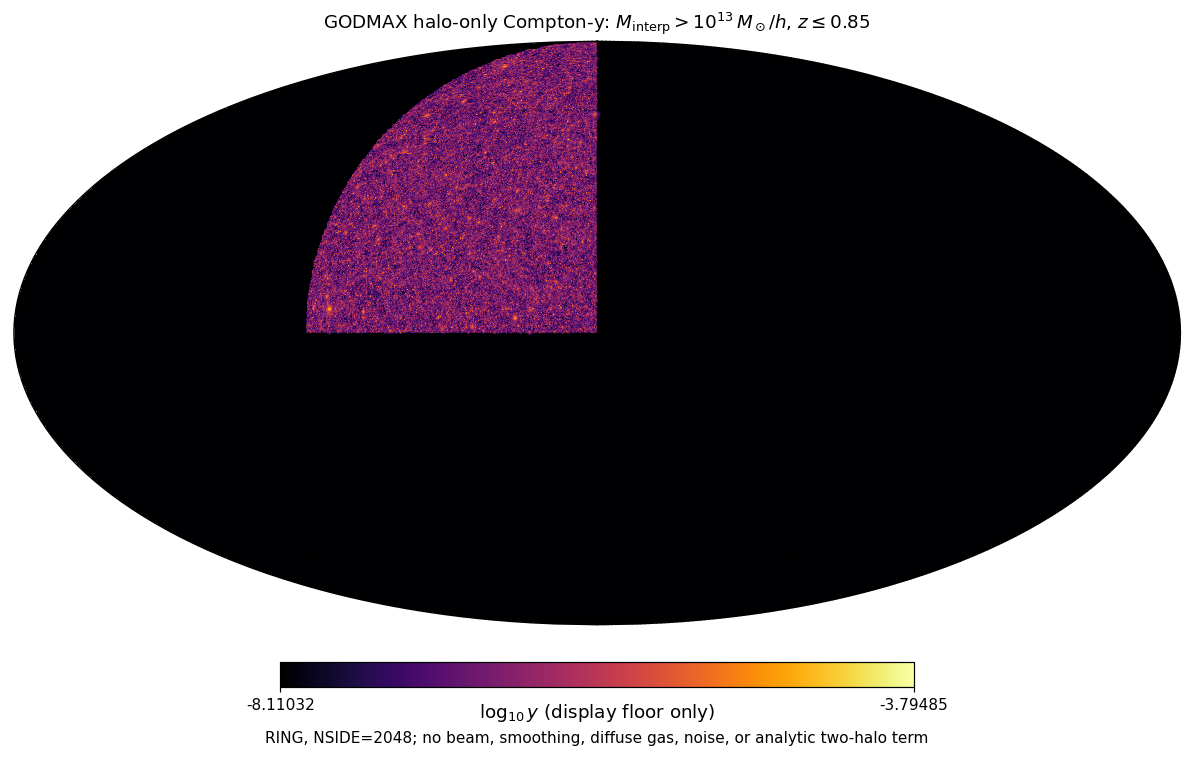

Saved /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis/tsz_map_nside2048_zle0p85_mollview.png


In [3]:
map_figure = diagnostics.plot_log_ymap(result['ymap'], result['map_metadata'])
map_png = OUTPUT_DIR / 'tsz_map_nside2048_zle0p85_mollview.png'
map_figure.savefig(map_png, bbox_inches='tight')
plt.show()
print(f'Saved {map_png}')

## Raw masked pseudo-angular-power spectra

The plotted points are $(2\ell+1)$-weighted logarithmic bins of $D_\ell=\ell(\ell+1)C_\ell/(2\pi)$. The compact HDF5 analysis product retains every unbinned $C_\ell$ and $D_\ell$. Negative halo-y bins, if present, remain visible on a symmetric-log axis.

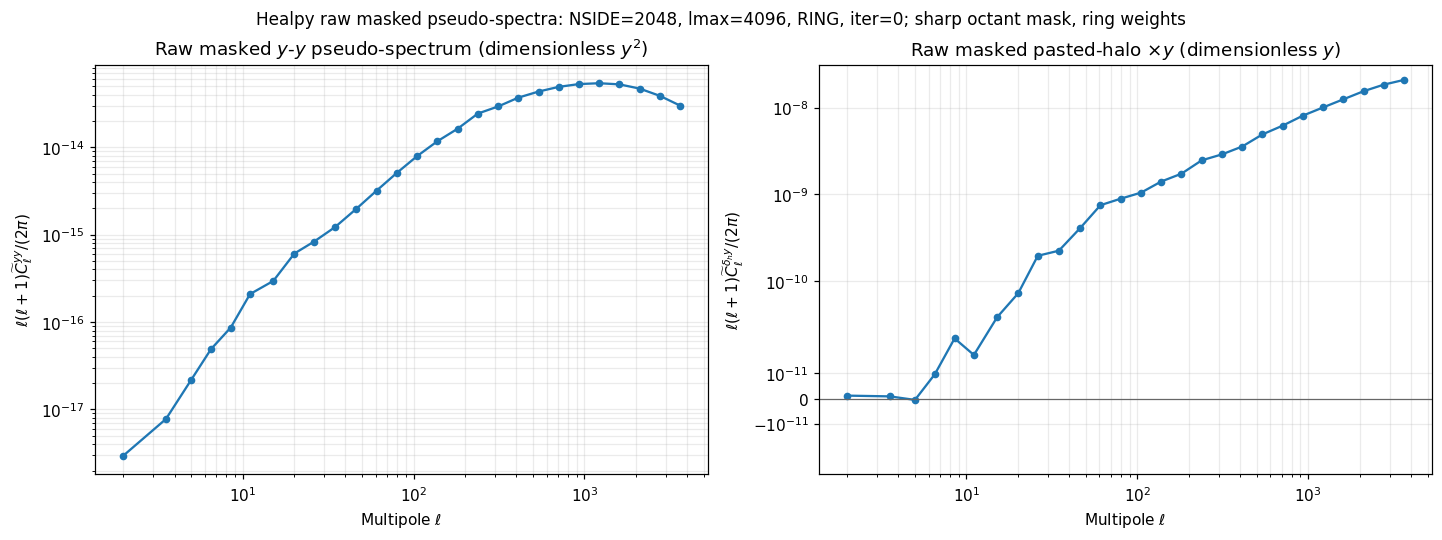

Saved /mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis/tsz_yy_halo_y_pseudo_dl_nside2048_lmax4096.png


In [4]:
spectra_figure = diagnostics.plot_binned_spectra(result['spectra'])
spectra_png = OUTPUT_DIR / 'tsz_yy_halo_y_pseudo_dl_nside2048_lmax4096.png'
spectra_figure.savefig(spectra_png, bbox_inches='tight')
plt.show()
print(f'Saved {spectra_png}')

## Final fail-closed checks

These assertions make the executed notebook itself show that it analyzed the same halo identities as the paste and did not modify the input product.

In [5]:
summary = result['summary']
checks = {
    'input_map_sha_unchanged': summary['map_sha_unchanged'],
    'selected_rows_exact': summary['selected_rows'] == diagnostics.EXPECTED_SELECTED_ROWS,
    'count_map_sum_exact': summary['count_map_sum'] == diagnostics.EXPECTED_SELECTED_ROWS,
    'selected_digest_exact': summary['selected_row_index_sha256'] == diagnostics.EXPECTED_SELECTED_SHA256,
    'all_halos_inside_footprint': summary['halos_outside_footprint'] == 0,
    'masked_halo_mean_near_zero': abs(summary['masked_halo_mean_after_centering']) < 1.0e-6,
    'masked_y_mean_near_zero': abs(summary['masked_y_mean_after_centering']) < 1.0e-12,
    'halo_pixels_have_enhanced_y': summary['halo_y_mean_enhancement_over_footprint'] > 1.0,
    'halo_y_bins_broadly_positive': summary['hy_positive_bin_fraction_ell20_3000'] >= 0.8,
    'yy_auto_nonnegative': summary['yy_min_cl'] >= -1.0e-30,
}
assert all(checks.values()), checks
print(json.dumps({
    'checks': checks,
    'spectra_hdf5': summary['spectra_path'],
    'map_png': str(map_png),
    'spectra_png': str(spectra_png),
}, indent=2, sort_keys=True))

{
  "checks": {
    "all_halos_inside_footprint": true,
    "count_map_sum_exact": true,
    "halo_pixels_have_enhanced_y": true,
    "halo_y_bins_broadly_positive": true,
    "input_map_sha_unchanged": true,
    "masked_halo_mean_near_zero": true,
    "masked_y_mean_near_zero": true,
    "selected_digest_exact": true,
    "selected_rows_exact": true,
    "yy_auto_nonnegative": true
  },
  "map_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis/tsz_map_nside2048_zle0p85_mollview.png",
  "spectra_hdf5": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis/tsz_halo_correlations_nside2048_lmax4096.h5",
  "spectra_png": "/mnt/ceph/users/spandey/ltu-godmax/GODMAX/data/DES_cluster/tsz_analysis/tsz_yy_halo_y_pseudo_dl_nside2048_lmax4096.png"
}
